## DATA PREPROCESSING AND DATA CLEANING

In [1]:
!pip install torch torchvision timm matplotlib scikit-learn

In [2]:
import zipfile

# Adjust name if your file name changes after re-upload
with zipfile.ZipFile("Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("Dataset")

print("✅ Extracted successfully!")

✅ Extracted successfully!


In [46]:
import os
import cv2
import torch
import timm
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import torchvision.transforms as transforms

# ==============================
# Device
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==============================
# Paths
# ==============================
train_dir = "/content/Dataset/Dataset/train"
val_dir   = "/content/Dataset/Dataset/val"

# ==============================
# Hyperparameters
# ==============================
batch_size = 2       # reduce if GPU memory issues
num_epochs = 10
learning_rate = 1e-4
num_frames = 8
image_size = 224

# ==============================
# Transform
# ==============================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((image_size, image_size)),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ==============================
# Video Dataset
# ==============================
class VideoDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        self.classes = sorted(os.listdir(root_dir))

        for label_idx, class_name in enumerate(self.classes):
            class_folder = os.path.join(root_dir, class_name)
            for file in os.listdir(class_folder):
                if file.endswith(".mp4"):
                    self.samples.append(
                        (os.path.join(class_folder, file), label_idx)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        cap = cv2.VideoCapture(video_path)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames == 0:
            raise ValueError(f"Cannot read video {video_path}")

        frame_ids = np.linspace(0, total_frames-1, num_frames, dtype=int)
        frames = []

        for fid in frame_ids:
            cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = transform(frame)
            frames.append(frame)

        cap.release()

        while len(frames) < num_frames:
            frames.append(frames[-1])

        frames = torch.stack(frames)  # (F, C, H, W)
        return frames, torch.tensor(label)

# ==============================
# Load datasets
# ==============================
train_dataset = VideoDataset(train_dir)
val_dataset   = VideoDataset(val_dir)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)

# ==============================
# Model: Xception + LSTM
# ==============================
class XceptionLSTM(nn.Module):
    def __init__(self, hidden_size=256, num_layers=1, num_classes=num_classes):
        super().__init__()
        self.cnn = timm.create_model('xception', pretrained=True, num_classes=2048)
        self.lstm = nn.LSTM(input_size=2048, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, num_frames, C, H, W = x.shape  # renamed F -> num_frames
        x = x.view(B*num_frames, C, H, W)
        features = self.cnn.forward_features(x)       # (B*F, 2048, Hf, Wf)
        features = F.adaptive_avg_pool2d(features, 1).view(B, num_frames, -1)  # (B, F, 2048)
        lstm_out, _ = self.lstm(features)            # (B, F, hidden_size)
        out = self.fc(lstm_out[:, -1, :])            # last frame prediction
        return out

model = XceptionLSTM(num_classes=num_classes).to(device)

# ==============================
# Loss & optimizer
# ==============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# ==============================
# Training loop
# ==============================
best_acc = 0

for epoch in range(num_epochs):
    # ---- TRAIN ----
    model.train()
    train_loss = 0
    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * videos.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for videos, labels in val_loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_video_model_xception_lstm.pth")

print("\n✅ Training Complete. Best Validation Accuracy:", best_acc)

Using device: cuda
Classes: ['Fake', 'Real']
Epoch 1/10 | Train Loss: 0.6252 | Val Acc: 0.8053
Epoch 2/10 | Train Loss: 0.4541 | Val Acc: 0.9078
Epoch 3/10 | Train Loss: 0.2845 | Val Acc: 0.9228
Epoch 4/10 | Train Loss: 0.2096 | Val Acc: 0.8689
Epoch 5/10 | Train Loss: 0.1291 | Val Acc: 0.9536
Epoch 6/10 | Train Loss: 0.1262 | Val Acc: 0.9706
Epoch 7/10 | Train Loss: 0.1034 | Val Acc: 0.9590
Epoch 8/10 | Train Loss: 0.0770 | Val Acc: 0.9802
Epoch 9/10 | Train Loss: 0.0796 | Val Acc: 0.9720
Epoch 10/10 | Train Loss: 0.0648 | Val Acc: 0.9617

✅ Training Complete. Best Validation Accuracy: 0.980191256830601


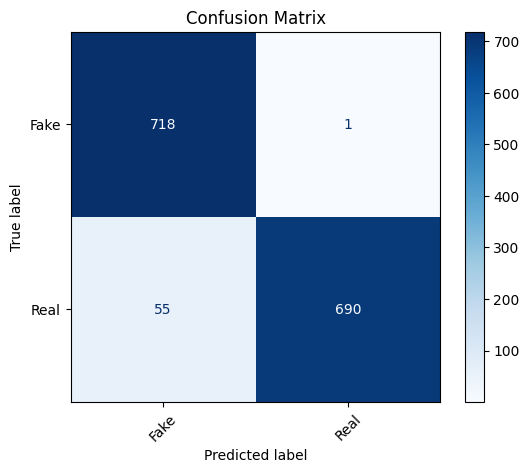

In [47]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make sure model is in evaluation mode
model.eval()

# Lists to store true and predicted labels
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = val_dataset.classes  # get class names from dataset

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [1]:
# ==============================
# 1️⃣ Upload File
# ==============================
from google.colab import files
uploaded = files.upload()

import torch
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os

# ==============================
# 2️⃣ Device
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# ==============================
# 3️⃣ Get Uploaded File
# ==============================
file_path = list(uploaded.keys())[0]
print("📂 Uploaded File:", file_path)

# ==============================
# 4️⃣ Transform (same as training)
# ==============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# ==============================
# 5️⃣ Image Prediction (4D)
# ==============================
def predict_image(img_path, model, transform, class_names):
    model.eval()

    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        predicted = torch.argmax(output, 1).item()

    return class_names[predicted]


# ==============================
# 6️⃣ Video Prediction (5D)
# ==============================
def predict_video(video_path, model, transform, class_names, num_frames=16):
    model.eval()
    cap = cv2.VideoCapture(video_path)

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return "❌ Could not read video"

    step = max(total_frames // num_frames, 1)
    frame_id = 0

    while len(frames) < num_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame)
        img = transform(img)
        frames.append(img)

        frame_id += step

    cap.release()

    if len(frames) == 0:
        return "❌ No frames extracted"

    # If less frames, pad with last frame
    while len(frames) < num_frames:
        frames.append(frames[-1])

    # (F, C, H, W)
    video_tensor = torch.stack(frames)

    # (1, F, C, H, W)
    video_tensor = video_tensor.unsqueeze(0).to(device)

    print("📊 Video Tensor Shape:", video_tensor.shape)

    with torch.no_grad():
        output = model(video_tensor)
        predicted = torch.argmax(output, 1).item()

    return class_names[predicted]


# ==============================
# 7️⃣ Auto Detect File Type
# ==============================
predicted_class = "❌ Prediction not executed"

ext = os.path.splitext(file_path)[1].lower()

try:
    if ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        predicted_class = predict_image(
            file_path, model, transform, val_dataset.classes
        )

    elif ext in ['.mp4', '.avi', '.mov']:
        predicted_class = predict_video(
            file_path, model, transform, val_dataset.classes
        )

    else:
        predicted_class = "❌ Unsupported file format"

except Exception as e:
    predicted_class = f"❌ Error during prediction: {str(e)}"

# ==============================
# 8️⃣ Print Result
# ==============================
print("✅ Predicted Class:", predicted_class)

Saving 174952-852215381_medium.mp4 to 174952-852215381_medium.mp4


NameError: name 'model' is not defined

In [ ]:
from google.colab import files

# Download your ViT model file
files.download('/content/vit_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>